#Multi-class Classification Problem
Now, that we have done the Binary classification problem, lets implement a Multi-class Model for the problem.

In [47]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import pandas as pd

In [48]:
#device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [49]:
#lets make some blobs
SAMPLES = 1000

x,y = make_blobs(SAMPLES, n_features = 2, centers=4)



In [50]:
#using pandas to visualize it
blobs = pd.DataFrame({"X1": x[:, 0],
                      "X2" : x[:, 1] ,
                      "Y" : y})
blobs.head(10)

,X1,X2,Y
0,2.263058,-1.288094,2
1,3.859010,1.240001,2
2,1.294151,-5.679914,0
3,3.454128,-2.431988,2
4,10.511359,7.360586,3
5,9.181506,7.476448,3
6,8.872507,8.861547,3
7,10.215694,5.937147,3
8,4.208862,-2.268328,2
9,10.265004,7.878987,3


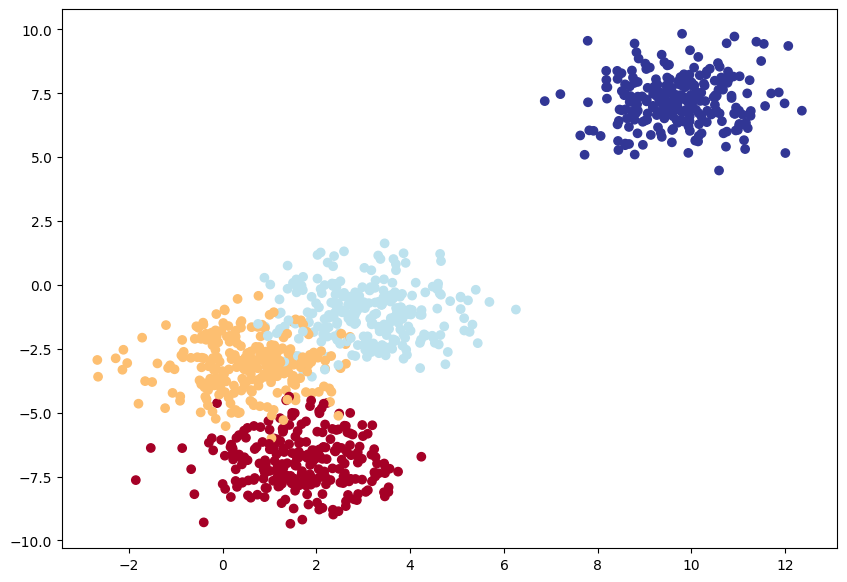

In [51]:
#lets plot it to see our blobs
#we should have 4 blobs
plt.figure(figsize=[10,7])
plt.scatter(x= x[:,0],
            y= x[:,1],
            c = y,
            cmap= plt.cm.RdYlBu)

In [52]:
def accuracy(y_input, y_target):
  equal = torch.eq(y_input, y_target).sum().item()
  accuracy_rate = (equal/len(y_input)) * 100
  return accuracy_rate

In [53]:
#converting to tensors and creating train and test splits
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x_train, x_test, y_train, y_test = train_test_split(x , y, test_size = 0.2,
                                                    random_state = 42)

len(x_train), len(x_test)

(800, 200)

In [54]:
#Lets build our model
model = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 64),
    nn.ReLU(),
    nn.Linear(in_features = 64, out_features = 64),
    nn.ReLU(),
    nn.Linear(in_features = 64, out_features = 4)
)
model

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=4, bias=True)
)

In [57]:
#Setting up Loss function and optimzier
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model.parameters(), lr= 0.1)

#training loop
torch.manual_seed(42)
epochs = 1000

#setup data
y_train, y_test = y_train.long(), y_test.long()

for epoch in range(epochs):
  model.train()

  #Forward pass
  y_train_logits = model(x_train)
  y_pred = torch.softmax(y_train_logits, dim = 1).argmax(dim=1)

  #calculate loss
  loss = loss_fn(y_train_logits, y_train)
  train_accuracy = accuracy(y_pred, y_train)

  #optimize zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  ###testing loop
  model.eval()
  with torch.inference_mode():
    #forward pass
    y_test_logits = model(x_test)
    y_test_pred = torch.softmax(y_test_logits, dim = 1).argmax(dim = 1)

    #calculate loss
    test_loss = loss_fn(y_test_logits, y_test)
    test_accuracy = accuracy(y_test_pred, y_test)

  #Print results every 100 epochs
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Train loss: {loss} Train Accuracy: {train_accuracy} | Test loss: {test_loss} Test Accuracy: {test_accuracy}")


Epoch: 0 | Train loss: 0.10098885744810104 Train Accuracy: 95.75 | Test loss: 0.05955963581800461 Test Accuracy: 97.5
Epoch: 100 | Train loss: 0.0989578515291214 Train Accuracy: 95.875 | Test loss: 0.05467874929308891 Test Accuracy: 97.5
Epoch: 200 | Train loss: 0.0993579775094986 Train Accuracy: 95.75 | Test loss: 0.05690748989582062 Test Accuracy: 97.5
Epoch: 300 | Train loss: 0.0999637097120285 Train Accuracy: 95.75 | Test loss: 0.05879979580640793 Test Accuracy: 97.5
Epoch: 400 | Train loss: 0.09870564192533493 Train Accuracy: 95.875 | Test loss: 0.056143492460250854 Test Accuracy: 97.5
Epoch: 500 | Train loss: 0.09860656410455704 Train Accuracy: 95.75 | Test loss: 0.05639345943927765 Test Accuracy: 97.5
Epoch: 600 | Train loss: 0.09831645339727402 Train Accuracy: 95.75 | Test loss: 0.05622513219714165 Test Accuracy: 98.0
Epoch: 700 | Train loss: 0.0980810821056366 Train Accuracy: 95.75 | Test loss: 0.05599299818277359 Test Accuracy: 98.0
Epoch: 800 | Train loss: 0.0979406088590622